# DEF-D Fysieke Ontwerpopdracht 5 Invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 25     |  |
| :-------------|:-------------|
| Bart de Jong | 5631598 |
| Ebe Polman| 6581455 |
| Amun Gomperts | 6557309 |

## Opdracht 1: Planning.

| Planning Groep: 25     |Tijdstip / Tijdspanne  | door wie  |
|---|---|---|
| Arduino testen| 12:30 | Ebe |
| ontwerp-eis berekenen| 12:30 | Bart & Amun|
| simulatie delta X | 14:00 | hele groep |
| fabricage | 15:00 | hele groep |
| proef metingen( + iteratie) | 15:30 | hele groep|
| metingen af | 17:00 | hele groep|
| Pauze 1| 12:30-13:30 | hele groep |
| Pauze 2| 15 | indien nodig  |

Run onderstaande cel om alle benodigde libraries te laden. Mogelijk voeg je er zelf nog een aantal toe later vandaag. 

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
import math

## Opdracht 2a: Opsplitsen taak 1: Arduino
Vul onderstaande tabel in:

| onderwerp    | antwoord  |
|---|---|
| hoe moeilijk (schaal 1 - 10) | 4 |
| hoe lang voor één meting | 3min |
| verwacht nauwkeurigheid meting | 0.3 |

## Opdracht 2b: Opsplitsen taak 2: afleiding ontwerpeis

$$
\frac{A_{m}}{A_{v}} = \frac{1}{1 - \frac{\omega^{2}}{\omega_{0}^{2}}} = minimaal \frac{1}{3}
$$
$$
\frac{\omega^{2}}{\omega_{0}^{2}} > 4
$$
$$
\omega^{2} = (2 \pi f)^{2}
$$

f = 5Hz

$$
\omega_{0}^{2} < 25\pi^{2}
$$
$$
\omega_{0} = 2 \pi f_{0} < 5\pi
$$
$$
f_{0} < \frac{5}{2} Hz
$$

C:\Users\bartd\AppData\Local\Temp\ipykernel_13240\3323445741.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


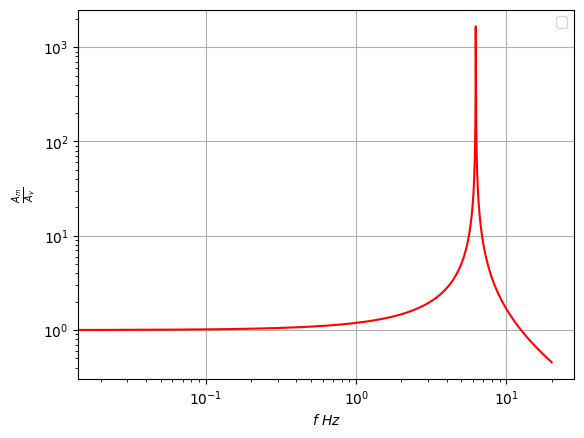

In [2]:
def model(f):
    global f0
    return (1)/(1 - ( f / (f0**2)))

f0 = 5/2
f = np.linspace(0, 20, 1000)
AmAv = model(f)

#plot
plt.figure()

plt.loglog(f, abs(AmAv), "r-")

plt.xlabel(r"$f$ $Hz$")
plt.ylabel(r"$\frac{A_{m}}{A_{v}}$")

plt.legend()
plt.grid()
plt.show()

In [3]:
g = 9.81 #m/s^2
f0 = 5/2 #Hz
w_0 = 2 * np.pi * f0
dX = g / (w_0**2)

print(f"de minimale Delta x die voldoed aan de eisen: {dX:.3}")

de minimale Delta x die voldoed aan de eisen: 0.0398


## Opdracht 3: Plot de grafiek.

de minimale waarde van dX die wij willen behalen:0.0621


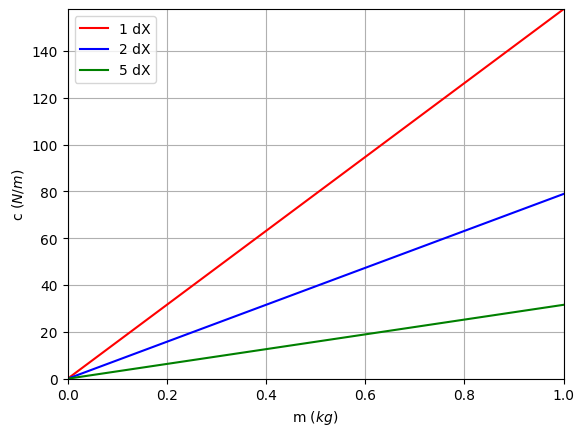

In [4]:
# Voeg hier je plot in. Lees goed de opdracht wat er in de grafiek moet staan!
# Het is ook handig om je grafiek op te slaan, doe dat door met plt.savefig().

g = 9.81 #m/s^2
f0 = 2 #Hz
w_0 = 2 * np.pi * f0
dX = g / (w_0**2)
print(f"de minimale waarde van dX die wij willen behalen:{dX:.3}")

def model1(m, dX):
    global g
    return (m * g) / dX

m = np.linspace(0, 1, 1000)
c1 = model1(m, dX)
c2 = model1(m, 2 * dX)
c3 = model1(m, 5 * dX)

#print(dX, 2 * dX, 5 * dX)

plt.figure()
plt.plot(m, c1, "r-", label = "1 dX")
plt.plot(m, c2, "b-", label = "2 dX")
plt.plot(m, c3, "g-", label = "5 dX")

plt.xlim(0, max(m))
plt.ylim(0, max(c1))
plt.xlabel(r"m $(kg)$")
plt.ylabel(r"c $(N/m)$")

plt.legend()
plt.grid()
plt.savefig("opdracht3.png")
plt.show()

## Opdracht 4: Verander $\Delta x$.

We kunnen $\Delta x$ verhogen door:

- massa verhogen
- veer constante verlagen

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

f0 moest kleiner zijn dan 2.5 wij hebben voor het berekenen van onze dX een f0 van 2 gekozen en hier is devolgende waarde uit gekomen
Als groep gaan we mikken op een $\Delta x$ van: 6.21 cm

In [5]:
#dit gebruiken we om te checken wat de maximale waarde van c is 
#en welke onze opstelling zou moeten hebben 

def model(L, A):
    global E
    return A * E / L

E = 1e6

#lengte van 1 elastiek
L = 0.105

#opp van een elastiek
A = 2e-6

#we gebruiken 6 elastieken (3 stengels van 2)
c = model(2 * L, 3 * A)

#de waarde van de veerconstante van ons systeem
print(f"{c:.4} N/m")

massa = 0.503
print("de maximale waarde van de veerconstante waar we onder moeten blijfen \n"+ 
      f"voor de massa die we gebruiken {model1(massa, dX):.4} N/m")

28.57 N/m
de maximale waarde van de veerconstante waar we onder moeten blijfen 
voor de massa die we gebruiken 79.43 N/m


## Opdracht 5: Schets.

##### schets opstelling: 
<img src="schets.jpeg" width="400">

## Opdracht 6: Beslissing evaluatie

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

6.3 cm

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

ja want we hebben een delta x van 22 cm

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

het ontwerp bestaat uit 2 elastiken die samen maximaal kunnen utirekken tot ongeveer
2 * 30 = 60cm

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

ja want de rust lengte + delta X = 2 * (10.5) + 22 = 43cm
wat betekend dat hij maximaal met een amplitude van 17 cm heen en weer kan gaan. 
en dit is meer dan genoeg

### Gaat je ontwerp dus voldoen aan de eis?

ja

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

Er zijn nog een aantal aanpassingen geweest door feetback van ta's

1: er zijn 2 extra elastieken toegevoegd waardoor hij in 3d gestabiliseerd wordt ipv 1d 

2: massa is verhoogd om een beter demping te geven

3: er is een sateprikker in de massa gestoken die op een hogere x ook word gestabiliseerd zodat de rotatie ook stabieler wordt 

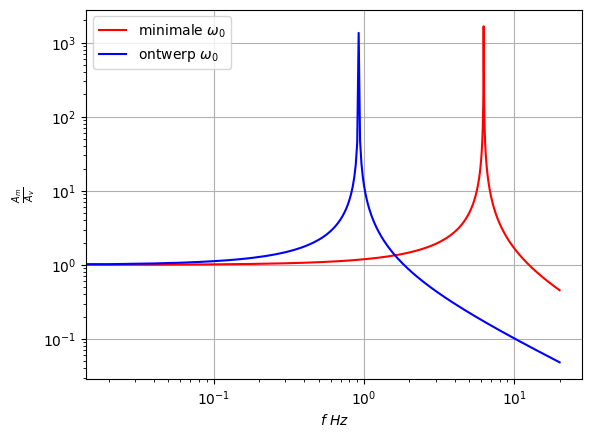

In [6]:
def model(f, f0):
    return (1)/(1 - ( f / (f0**2)))

f0_theorie = 5/2
f = np.linspace(0, 20, 1000)
AmAv = model(f, f0_theorie)

f0_ontwerp = 0.96
AmAv_ontwerp = model(f, f0_ontwerp)

#plot
plt.figure()

plt.loglog(f, abs(AmAv), "r-", label = r"minimale $\omega_0$")
plt.loglog(f, abs(AmAv_ontwerp), "b-", label = r"ontwerp $\omega_0$")

plt.xlabel(r"$f$ $Hz$")
plt.ylabel(r"$\frac{A_{m}}{A_{v}}$")

plt.legend()
plt.grid()
plt.show()

## Opdracht 7: Plotten maar

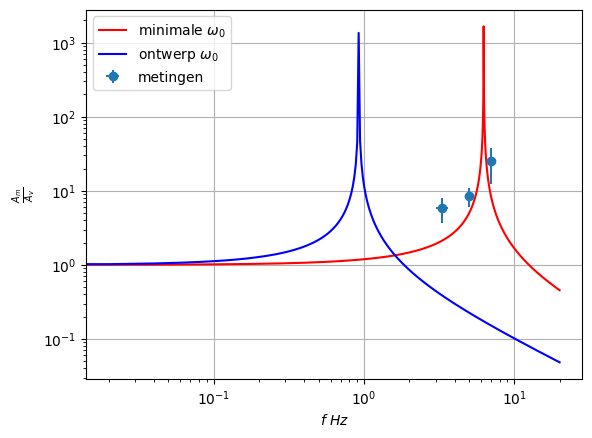

In [7]:
def model(f, f0):
    return (1)/(1 - ( f / (f0**2)))

f0_theorie = 5/2
f = np.linspace(0, 20, 1000)
AmAv = model(f, f0_theorie)

f0_ontwerp = 0.96
AmAv_ontwerp = model(f, f0_ontwerp)

f_meting = np.array([3.3, 5, 7])
Am = np.array([5 ,6 ,5 ])
Av = np.array([0.85 ,0.7 ,0.2 ])
AmAv_meting = Am / Av

# voor de metingen hebben we de frequentie binen deze rqange weten te houden
uf = 0.3
uAm = np.array([0.6,0.4,0.5])
uAv = np.array([0.3,0.2,0.1])

uAmAv = np.sqrt((uAm / Av)**2 + (uAv * Am/(Av**2))**2)

#plot
plt.figure()

plt.loglog(f, abs(AmAv), "r-", label = r"minimale $\omega_0$")
plt.loglog(f, abs(AmAv_ontwerp), "b-", label = r"ontwerp $\omega_0$")
plt.errorbar(f_meting, AmAv_meting, xerr = uf, yerr = uAmAv, fmt = "o"
             , label = "metingen")


plt.xlabel(r"$f$ $Hz$")
plt.ylabel(r"$\frac{A_{m}}{A_{v}}$")

plt.legend()
plt.grid()
plt.savefig("opdracht7.1.png")
plt.show()

## Opdracht 8: Leerdoelen
Voeg hieronder zelf kopjes toe om aan te geven wat bij welk leerdoel hoort. 

## leerdoel 1
# Inzien dat de parameters in een differentiaalvergelijking ontwerpparameters zijn die een ontwerpruimte opspannen.

$$
\frac{A_{m}}{A_{v}} = \frac{1}{1 - \frac{\omega^{2}}{\omega_{0}^{2}}} = minimaal \frac{1}{3}
$$
$$
\frac{\omega^{2}}{\omega_{0}^{2}} > 4
$$
$$
\omega^{2} = (2 \pi f)^{2}
$$

f = 5Hz

$$
\omega_{0}^{2} < 25\pi^{2}
$$
$$
\omega_{0} = 2 \pi f_{0} < 5\pi
$$
$$
f_{0} < \frac{5}{2} Hz
$$

hieruit maken wij op dat we een ontwerp moeten maken die kleiner dan deze $f_{0}$ waarde 

op basis hier van krijgen wij een minimale DX die wij kunnen behalen door een balans te  vinden tussen de massa die wordt gestabiliseerd, de lengte van de veren en het oppervlakte van de/aantal veren. 

$$
F_{z} = F_{k} 
$$
$$
 m * g = c * DX = (\frac{A * E}{L}) * DX
$$


## leerdoel 2:
# Op basis van een differentiaal vergelijking een keuze maken voor parameters en die vervolgens kunnen vertalen in een fysiek ontwerp.

In [8]:
#dit gebruiken we om te checken wat de maximale waarde van c is 
#en welke onze opstelling zou moeten hebben 
 
def model(L, A):
    global E
    return A * E / L

E = 1e6

#lengte van 1 elastiek
L = 0.105

#opp van een elastiek
A = 2e-6

#we gebruiken 6 elastieken (3 stengels van 2)
c = model(2 * L, 3 * A)

#de waarde van de veerconstante van ons systeem
print(f"{c:.4} N/m")

massa = 0.503
print("de maximale waarde van de veerconstante waar we onder moeten blijfen \n"+ 
      f"voor de massa die we gebruiken {model1(massa, dX):.4} N/m")

28.57 N/m
de maximale waarde van de veerconstante waar we onder moeten blijfen 
voor de massa die we gebruiken 79.43 N/m


<img src="opdracht3.png" width="400">
<img src="opdracht7.1.png" width="400">